In [1]:
from pathlib import Path
%cd ..
csd_path = Path('./data/csds')
csd_path.exists()

/home/rehak/repos/ops/ecris.analysis


True

In [41]:
from random import randint
from ops.ecris.analysis.io.read_csd_file import read_csd_from_file_pair
csd_files = list(csd_path.glob('csd_*'))
csds = [read_csd_from_file_pair(csd_files[randint(0, len(csd_files) - 1)]) for _ in range(1)]

In [42]:
from ops.ecris.analysis.csd.m_over_q import estimate_m_over_q

for csd in csds:
    csd.m_over_q = estimate_m_over_q(csd)

In [43]:
csds.extend(kept_csds)

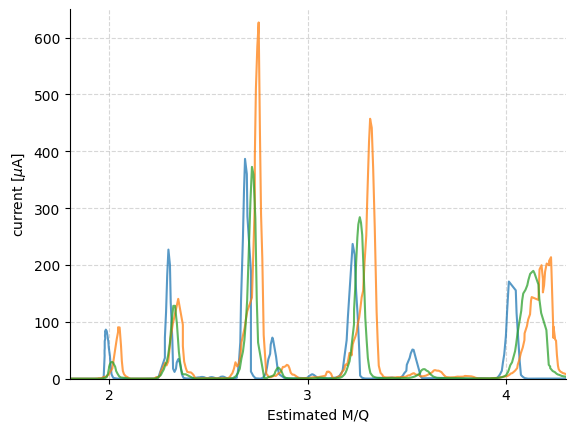

In [67]:
import matplotlib.pyplot as plt
markers = ['x', '']
for csd in csds:
    plt.plot(csd.m_over_q, csd.beam_current, alpha=0.75)
    plt.grid(alpha=0.5, ls='--')
    plt.ylabel(r'current [$\mu$A]')
    plt.xticks(range(1, 10))
    plt.xlim(1.8, 4.3)
    plt.ylim(0, 650)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xlabel('Estimated M/Q')
plt.show()

In [69]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np
import joblib

In [74]:
X = np.load('./models/oxygen_nn/x_training.npy')
Y = np.load('./models/oxygen_nn/y_training.npy')
X.shape
np.sum(Y)

np.int64(302)